In [38]:
import matplotlib.pyplot as plt
import numpy as np

In [39]:
chapter = 'K1'

In [40]:
savefolder = f'../img/{chapter}/'

In [41]:
# ============================================================
# Standard-Einstellungen
# ============================================================
from matplotlib.transforms import blended_transform_factory

DEFAULT_COLORS = {
    "primary": "#1f77b4",      # Hauptfarbe
    "secondary": "#ff7f0e",    # Zweitfarbe
    "accent": "#2ca02c",       # Akzentfarbe
    "grid": "#d0d0d0",
    "axes": "black"
}


def setup_plot(
    figsize=(6, 4),
    show_ticks=False,
    xlabel="x",
    ylabel="y",
    xlim=None,
    ylim=None,
    grid=False,
    colors=None
):
    """
    Erstellt ein Koordinatensystem mit Achsen durch den Ursprung.

    Parameters
    ----------
    show_ticks : bool
        Achsenbeschriftungen anzeigen?
    """

    if colors is None:
        colors = DEFAULT_COLORS

    fig, ax = plt.subplots(figsize=figsize)

    # Achsen durch den Ursprung
    ax.spines["top"].set_color("none")
    ax.spines["right"].set_color("none")

    ax.spines["bottom"].set_position("zero")
    ax.spines["left"].set_position("zero")

    ax.spines["bottom"].set_color(colors["axes"])
    ax.spines["left"].set_color(colors["axes"])

    # # Achsenbeschriftungen
    # ax.set_xlabel(xlabel)
    # ax.set_ylabel(ylabel)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()


    # Tickmarks
    if not show_ticks:
        ax.set_xticks([])
        ax.set_yticks([])

    # Grenzen
    if xlim is not None:
        ax.set_xlim(*xlim)

    if ylim is not None:
        ax.set_ylim(*ylim)

    # Achsenbeschriftungen
    trans_x = blended_transform_factory(ax.transAxes, ax.transData)
    trans_y = blended_transform_factory(ax.transData, ax.transAxes)

    ax.text(
        1.02,      # etwas rechts vom Plot
        0,         # y = 0
        xlabel,
        transform=trans_x,
        ha="left",
        va="center"
    )

    ax.text(
        0,         # x = 0
        1.02,      # etwas oberhalb des Plots
        ylabel,
        transform=trans_y,
        ha="center",
        va="bottom"
    )

    # Gitter
    if grid:
        ax.grid(
            True,
            color=colors["grid"],
            linestyle="--",
            alpha=0.35
        )

    return fig, ax

In [42]:
def quadratic_func(x):
    return x**2

def cubic_func(x):
    return x**3

def linear_func(x):
    return x

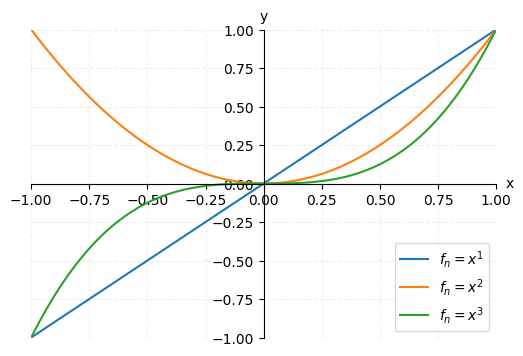

In [43]:
x_space = np.linspace(-1,1,100)

fig, ax = setup_plot(
    show_ticks=True,
    xlim=(-1, 1),
    ylim=(-1, 1),
    grid=True
)

plt.plot(
    x_space,
    linear_func(x_space),
    label='$f_n = x^1$'
)

plt.plot(
    x_space,
    quadratic_func(x_space),
    label='$f_n = x^2$'
)

plt.plot(
    x_space,
    cubic_func(x_space),
    label='$f_n = x^3$'
)

plt.legend()
plt.savefig(f'{savefolder}Beispiel_L2_Konvergenz.pdf')
plt.show()

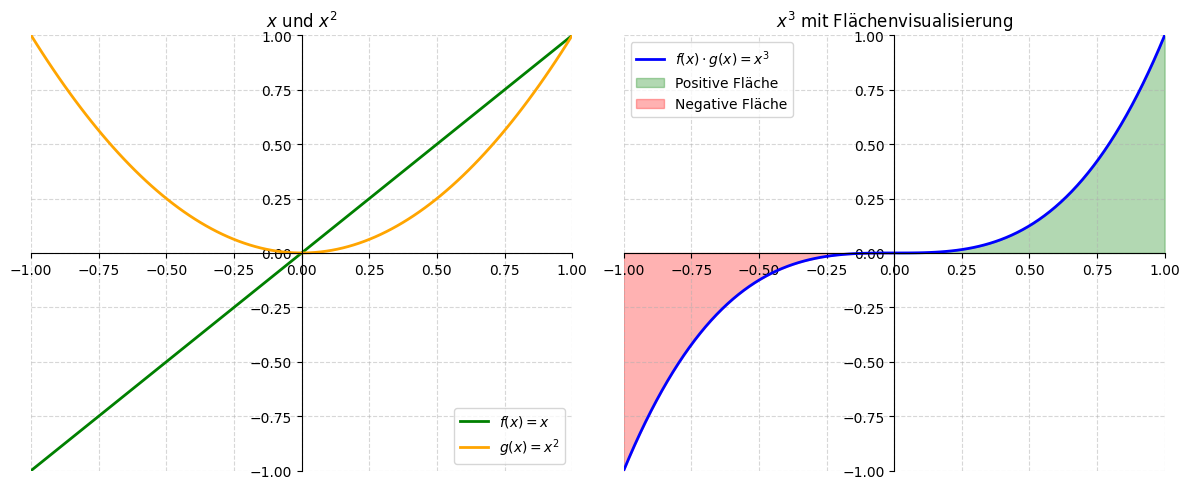

In [44]:
x_space = np.linspace(-1, 1, 100)

# Erstelle Figure mit zwei Subplots nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# === Funktionen für Achsenkreuz setzen ===
def set_axes_cross(ax):
    """Verschiebt die Achsen zum Ursprung und blendet Rahmen aus"""
    ax.spines['bottom'].set_position('center')  # x-Achse bei y=0
    ax.spines['left'].set_position('center')    # y-Achse bei x=0
    
    # Rechte und obere Achse verstecken
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    
    # Pfeilspitzen für die Achsen hinzufügen (optional)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    
    # Gitterlinien beibehalten
    ax.grid(True, linestyle='--', alpha=0.5)


# === Linker Plot: x^1 und x^2 ===
ax_left = axes[0]
set_axes_cross(ax_left)

ax_left.set_xlim(-1, 1)
ax_left.set_ylim(-1, 1)

ax_left.plot(
    x_space,
    linear_func(x_space),
    label='$f(x) = x$',
    color='green',
    linewidth=2
)

ax_left.plot(
    x_space,
    quadratic_func(x_space),
    label='$g(x) = x^2$',
    color='orange',
    linewidth=2
)

ax_left.legend(loc='lower right')
ax_left.set_title('$x$ und $x^2$')


# === Rechter Plot: x^3 mit Fläche ===
ax_right = axes[1]
set_axes_cross(ax_right)

ax_right.set_xlim(-1, 1)
ax_right.set_ylim(-1, 1)

ax_right.plot(
    x_space,
    cubic_func(x_space),
    label=r'$f(x) \cdot g(x) = x^3$',
    color='blue',
    linewidth=2
)


# Nur über der x-Achse
ax_right.fill_between(x_space, cubic_func(x_space), 0, where=cubic_func(x_space) >= 0, 
                      alpha=0.3, color='green', label='Positive Fläche')

# Unter der x-Achse separat
ax_right.fill_between(x_space, cubic_func(x_space), 0, where=cubic_func(x_space) < 0, 
                      alpha=0.3, color='red', label='Negative Fläche')

ax_right.legend(loc='upper left')
ax_right.set_title('$x^3$ mit Flächenvisualisierung')


# Gesamte Figur speichern und anzeigen
plt.tight_layout()
plt.savefig(f'{savefolder}Orthogonale_Funktionen.pdf')
plt.show()

In [45]:
def c_k(k, x):
    return np.cos(k * x)

def s_l(l, x):
    return np.sin(l * x)

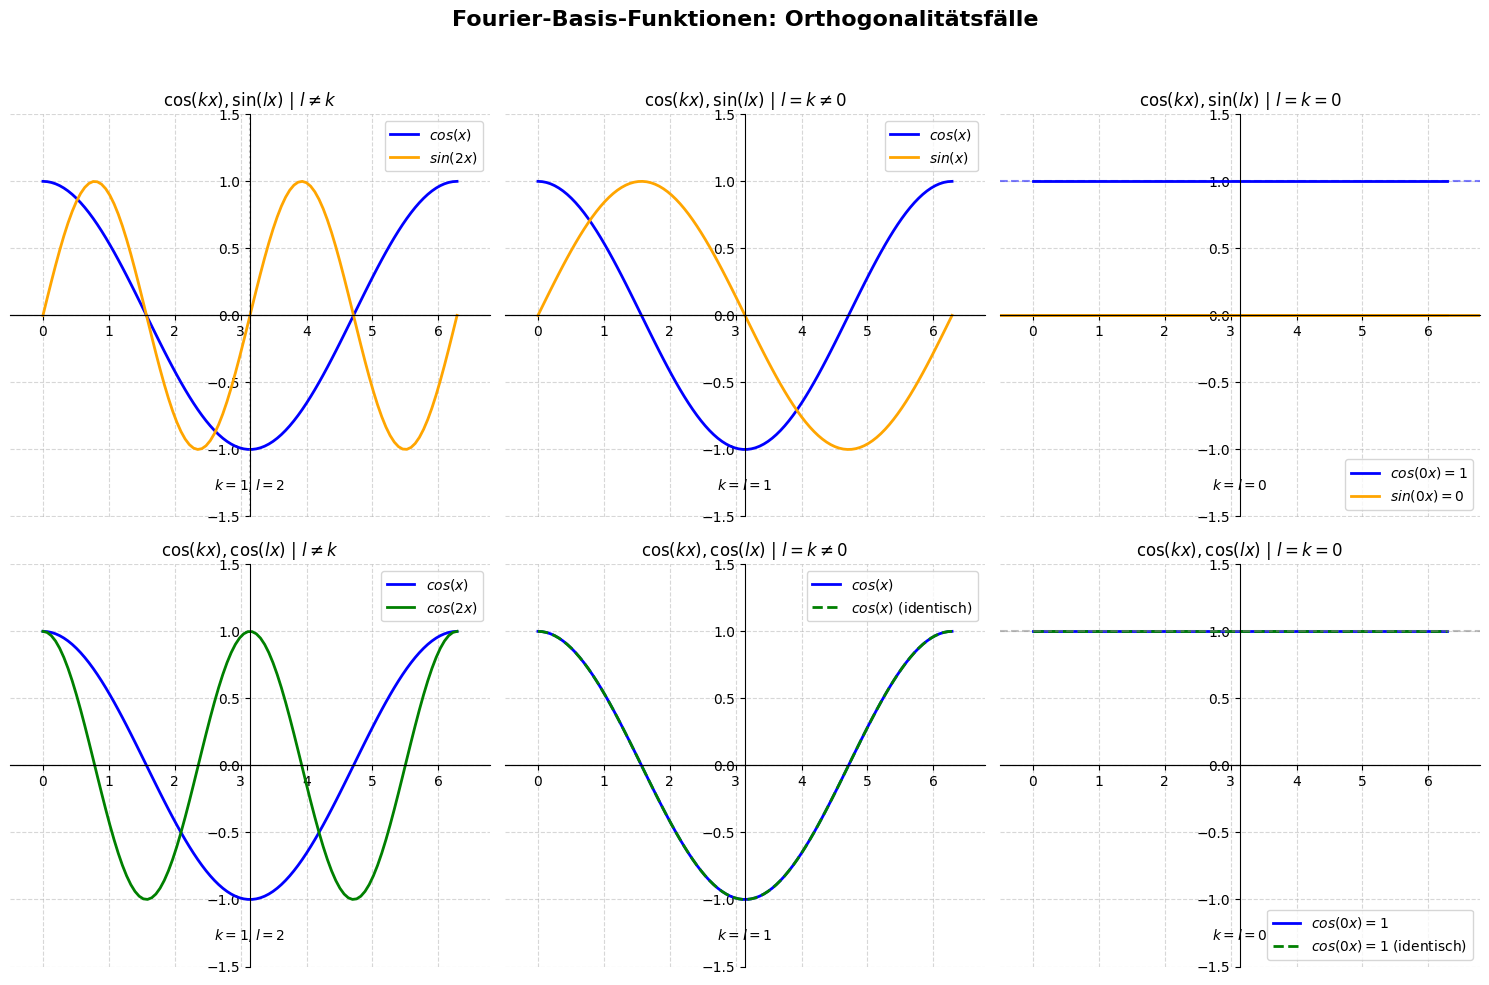

In [46]:
x_space = np.linspace(0, 2 * np.pi, 100)

# Erstelle Figure mit 2 Zeilen, 3 Spalten
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# === Zeile 1: Cos-Sin Kombinationen ===

# Fall 1: Cos-Sin | l ≠ k
ax1 = axes[0, 0]
set_axes_cross(ax1)
ax1.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label='$cos(x)$')
ax1.plot(x_space, s_l(2, x_space), color='orange', linewidth=2, label='$sin(2x)$')
ax1.set_xlim(-0.5, 2*np.pi + 0.5)
ax1.set_ylim(-1.5, 1.5)
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axvline(x=np.pi, color='gray', linestyle=':', alpha=0.5)  # Orientierungshilfe
ax1.legend(loc='upper right')
ax1.set_title(r'$\cos(kx), \sin(lx)$ | $l \neq k$')
ax1.text(np.pi, -1.3, r'$k=1, l=2$', ha='center')

# Fall 2: Cos-Sin | l = k ≠ 0
ax2 = axes[0, 1]
set_axes_cross(ax2)
ax2.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label='$cos(x)$')
ax2.plot(x_space, s_l(1, x_space), color='orange', linewidth=2, label='$sin(x)$')
ax2.set_xlim(-0.5, 2*np.pi + 0.5)
ax2.set_ylim(-1.5, 1.5)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.legend(loc='upper right')
ax2.set_title(r'$\cos(kx), \sin(lx)$ | $l = k \neq 0$')
ax2.text(np.pi, -1.3, r'$k=l=1$', ha='center')

# Fall 3: Cos-Sin | l = k = 0
ax3 = axes[0, 2]
set_axes_cross(ax3)
ax3.plot(x_space, c_k(0, x_space), color='blue', linewidth=2, label=r'$cos(0x) = 1$')
ax3.plot(x_space, s_l(0, x_space), color='orange', linewidth=2, label=r'$sin(0x) = 0$')
ax3.axhline(y=1, color='blue', linestyle='--', alpha=0.5)
ax3.axhline(y=0, color='orange', linestyle='-', linewidth=2)
ax3.set_xlim(-0.5, 2*np.pi + 0.5)
ax3.set_ylim(-1.5, 1.5)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.legend(loc='lower right')
ax3.set_title(r'$\cos(kx), \sin(lx)$ | $l = k = 0$')
ax3.text(np.pi, -1.3, r'$k=l=0$', ha='center')


# === Zeile 2: Cos-Cos Kombinationen ===

# Fall 4: Cos-Cos | l ≠ k
ax4 = axes[1, 0]
set_axes_cross(ax4)
ax4.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label=r'$cos(x)$')
ax4.plot(x_space, c_k(2, x_space), color='green', linewidth=2, label=r'$cos(2x)$')
ax4.set_xlim(-0.5, 2*np.pi + 0.5)
ax4.set_ylim(-1.5, 1.5)
ax4.axhline(y=0, color='black', linewidth=0.8)
ax4.legend(loc='upper right')
ax4.set_title(r'$\cos(kx), \cos(lx)$ | $l \neq k$')
ax4.text(np.pi, -1.3, r'$k=1, l=2$', ha='center')

# Fall 5: Cos-Cos | l = k ≠ 0
ax5 = axes[1, 1]
set_axes_cross(ax5)
ax5.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label=r'$cos(x)$')
ax5.plot(x_space, c_k(1, x_space), color='green', linewidth=2, linestyle='--', label=r'$cos(x)$ (identisch)')
ax5.set_xlim(-0.5, 2*np.pi + 0.5)
ax5.set_ylim(-1.5, 1.5)
ax5.axhline(y=0, color='black', linewidth=0.8)
ax5.legend(loc='upper right')
ax5.set_title(r'$\cos(kx), \cos(lx)$ | $l = k \neq 0$')
ax5.text(np.pi, -1.3, r'$k=l=1$', ha='center')

# Fall 6: Cos-Cos | l = k = 0
ax6 = axes[1, 2]
set_axes_cross(ax6)
ax6.plot(x_space, c_k(0, x_space), color='blue', linewidth=2, label=r'$cos(0x) = 1$')
ax6.plot(x_space, c_k(0, x_space), color='green', linewidth=2, linestyle='--', label=r'$cos(0x) = 1$ (identisch)')
ax6.set_xlim(-0.5, 2*np.pi + 0.5)
ax6.set_ylim(-1.5, 1.5)
ax6.axhline(y=0, color='black', linewidth=0.8)
ax6.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax6.legend(loc='lower right')
ax6.set_title(r'$\cos(kx), \cos(lx)$ | $l = k = 0$')
ax6.text(np.pi, -1.3, r'$k=l=0$', ha='center')


plt.suptitle('Fourier-Basis-Funktionen: Orthogonalitätsfälle', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Platz für Titel lassen

# Speichern und anzeigen
plt.savefig(f'{savefolder}Fourier_Basis_Funktionen.pdf')
plt.show()

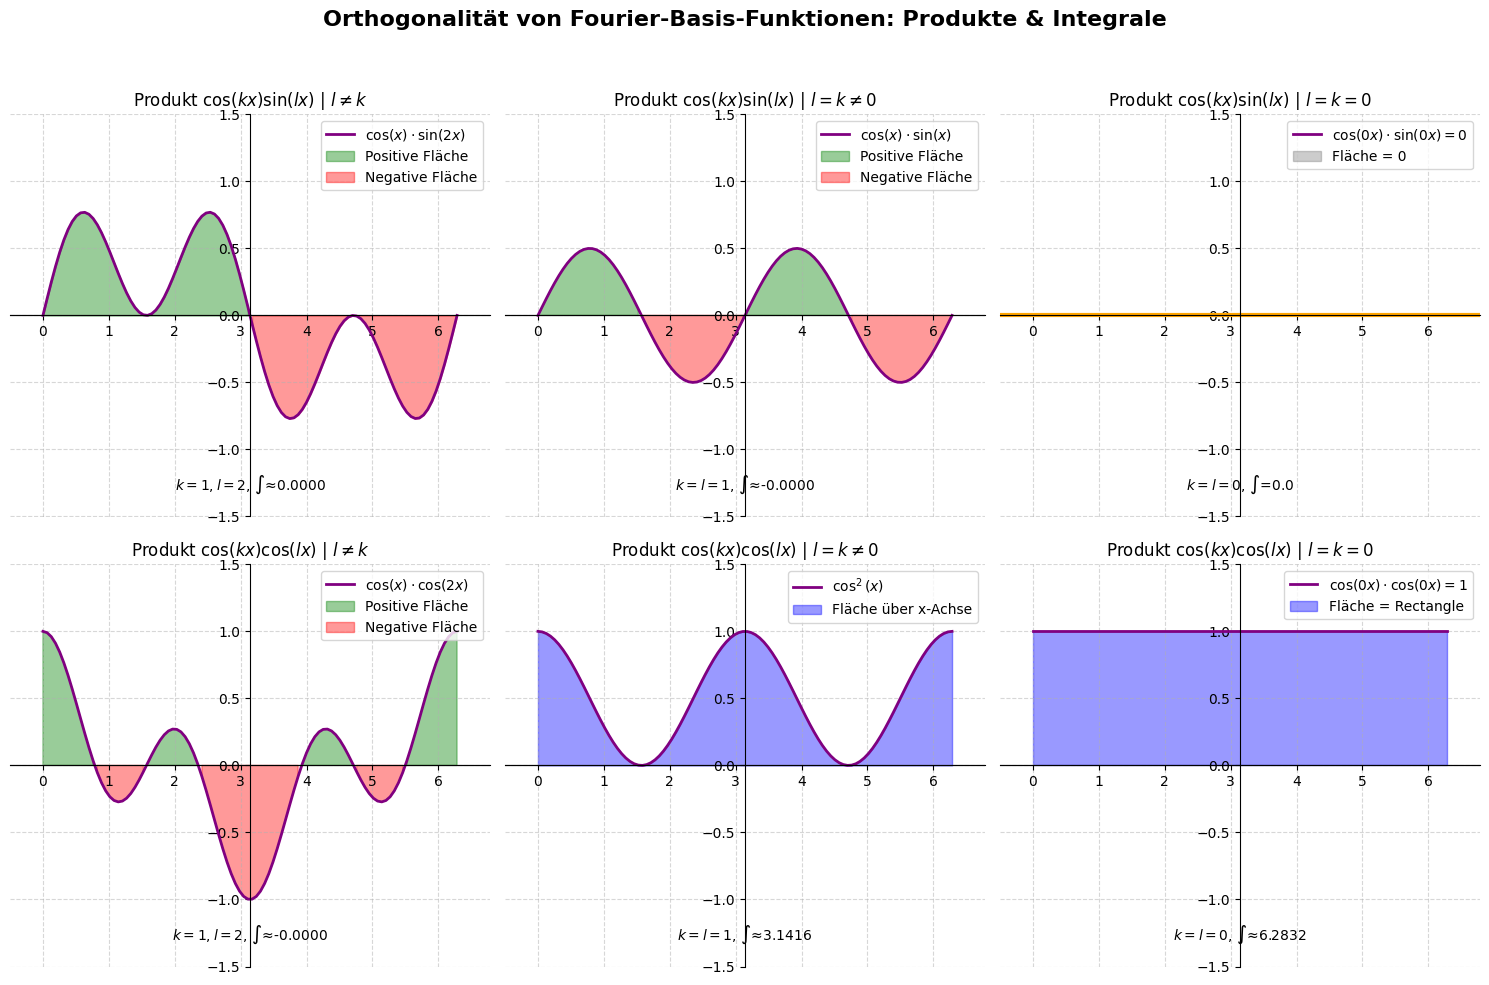

In [47]:
x_space = np.linspace(0, 2 * np.pi, 100)

# Erstelle Figure mit 2 Zeilen, 3 Spalten
fig, axes = plt.subplots(2, 3, figsize=(15, 10))


# === Zeile 1: Cos × Sin Produkte ===

# Fall 1: Cos×Sin | l ≠ k
ax1 = axes[0, 0]
set_axes_cross(ax1)
product_1 = c_k(1, x_space) * s_l(2, x_space)
ax1.plot(x_space, product_1, color='purple', linewidth=2, label=r'$\cos(x) \cdot \sin(2x)$')
ax1.fill_between(x_space, product_1, 0, 
                 where=product_1 >= 0, alpha=0.4, color='green', label='Positive Fläche')
ax1.fill_between(x_space, product_1, 0, 
                 where=product_1 < 0, alpha=0.4, color='red', label='Negative Fläche')
ax1.set_xlim(-0.5, 2*np.pi + 0.5)
ax1.set_ylim(-1.5, 1.5)
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.legend(loc='upper right')
ax1.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l \neq k$')
integral_value_1 = np.trapezoid(product_1, x_space)
ax1.text(np.pi, -1.3, f'$k=1, l=2$, ∫≈{integral_value_1:.4f}', ha='center')

# Fall 2: Cos×Sin | l = k ≠ 0
ax2 = axes[0, 1]
set_axes_cross(ax2)
product_2 = c_k(1, x_space) * s_l(1, x_space)
ax2.plot(x_space, product_2, color='purple', linewidth=2, label=r'$\cos(x) \cdot \sin(x)$')
ax2.fill_between(x_space, product_2, 0, 
                 where=product_2 >= 0, alpha=0.4, color='green', label='Positive Fläche')
ax2.fill_between(x_space, product_2, 0, 
                 where=product_2 < 0, alpha=0.4, color='red', label='Negative Fläche')
ax2.set_xlim(-0.5, 2*np.pi + 0.5)
ax2.set_ylim(-1.5, 1.5)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.legend(loc='upper right')
ax2.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l = k \neq 0$')
integral_value_2 = np.trapezoid(product_2, x_space)
ax2.text(np.pi, -1.3, f'$k=l=1$, ∫≈{integral_value_2:.4f}', ha='center')

# Fall 3: Cos×Sin | l = k = 0
ax3 = axes[0, 2]
set_axes_cross(ax3)
product_3 = c_k(0, x_space) * s_l(0, x_space)  # = 1 × 0 = 0
ax3.plot(x_space, product_3, color='purple', linewidth=2, label=r'$\cos(0x) \cdot \sin(0x) = 0$')
ax3.fill_between(x_space, product_3, 0, alpha=0.4, color='gray', label='Fläche = 0')
ax3.set_xlim(-0.5, 2*np.pi + 0.5)
ax3.set_ylim(-1.5, 1.5)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.axhline(y=0, color='orange', linestyle='-', linewidth=3)  # Highlight x-Achse
ax3.legend(loc='upper right')
ax3.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l = k = 0$')
integral_value_3 = np.trapezoid(product_3, x_space)
ax3.text(np.pi, -1.3, f'$k=l=0$, ∫={integral_value_3}', ha='center')


# === Zeile 2: Cos × Cos Produkte ===

# Fall 4: Cos×Cos | l ≠ k
ax4 = axes[1, 0]
set_axes_cross(ax4)
product_4 = c_k(1, x_space) * c_k(2, x_space)
ax4.plot(x_space, product_4, color='purple', linewidth=2, label=r'$\cos(x) \cdot \cos(2x)$')
ax4.fill_between(x_space, product_4, 0, 
                 where=product_4 >= 0, alpha=0.4, color='green', label='Positive Fläche')
ax4.fill_between(x_space, product_4, 0, 
                 where=product_4 < 0, alpha=0.4, color='red', label='Negative Fläche')
ax4.set_xlim(-0.5, 2*np.pi + 0.5)
ax4.set_ylim(-1.5, 1.5)
ax4.axhline(y=0, color='black', linewidth=0.8)
ax4.legend(loc='upper right')
ax4.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l \neq k$')
integral_value_4 = np.trapezoid(product_4, x_space)
ax4.text(np.pi, -1.3, f'$k=1, l=2$, ∫≈{integral_value_4:.4f}', ha='center')

# Fall 5: Cos×Cos | l = k ≠ 0
ax5 = axes[1, 1]
set_axes_cross(ax5)
product_5 = c_k(1, x_space) * c_k(1, x_space)  # = cos²(x)
ax5.plot(x_space, product_5, color='purple', linewidth=2, label=r'$\cos^2(x)$')
ax5.fill_between(x_space, product_5, 0, alpha=0.4, color='blue', label='Fläche über x-Achse')
ax5.set_xlim(-0.5, 2*np.pi + 0.5)
ax5.set_ylim(-1.5, 1.5)
ax5.axhline(y=0, color='black', linewidth=0.8)
# ax5.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)  # Mittelwert y=0.5
ax5.legend(loc='upper right')
ax5.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l = k \neq 0$')
integral_value_5 = np.trapezoid(product_5, x_space)
ax5.text(np.pi, -1.3, f'$k=l=1$, ∫≈{integral_value_5:.4f}', ha='center')

# Fall 6: Cos×Cos | l = k = 0
ax6 = axes[1, 2]
set_axes_cross(ax6)
product_6 = c_k(0, x_space) * c_k(0, x_space)  # = 1 × 1 = 1
ax6.plot(x_space, product_6, color='purple', linewidth=2, label=r'$\cos(0x) \cdot \cos(0x) = 1$')
ax6.fill_between(x_space, product_6, 0, alpha=0.4, color='blue', label='Fläche = Rectangle')
ax6.set_xlim(-0.5, 2*np.pi + 0.5)
ax6.set_ylim(-1.5, 1.5)
ax6.axhline(y=0, color='black', linewidth=0.8)
# ax6.axhline(y=1, color='gray', linestyle='--', alpha=0.5)  # Niveau y=1
ax6.legend(loc='upper right')
ax6.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l = k = 0$')
integral_value_6 = np.trapezoid(product_6, x_space)
ax6.text(np.pi, -1.3, f'$k=l=0$, ∫≈{integral_value_6:.4f}', ha='center')


plt.suptitle('Orthogonalität von Fourier-Basis-Funktionen: Produkte & Integrale', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Speichern und anzeigen
plt.savefig(f'{savefolder}Fourier_Produkte_Flaechen.pdf')
plt.show()

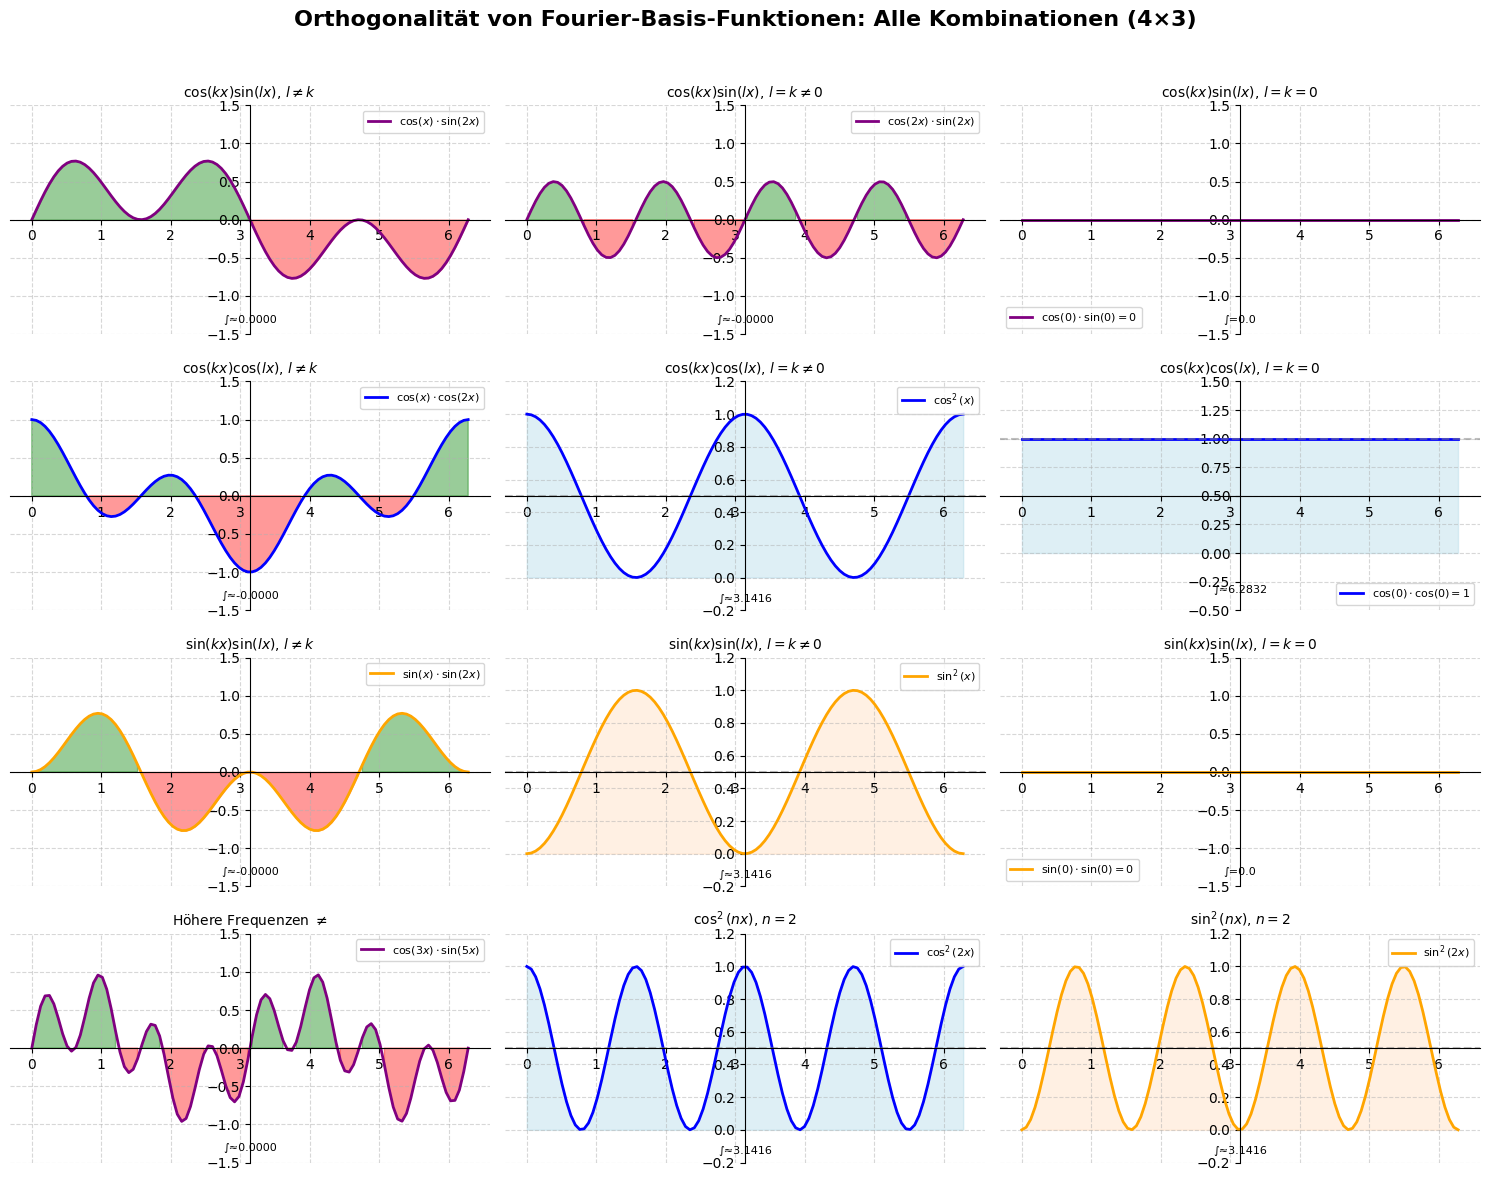

In [ ]:
# x_space = np.linspace(0, 2 * np.pi, 100)

# # Erstelle Figure mit 4 Zeilen, 3 Spalten
# fig, axes = plt.subplots(4, 3, figsize=(15, 12))

# # === Zeile 1: Cos × Sin Produkte ===

# # Fall 1: Cos×Sin | l ≠ k
# ax1 = axes[0, 0]
# set_axes_cross(ax1)
# product_1 = c_k(1, x_space) * s_l(2, x_space)
# ax1.plot(x_space, product_1, color='purple', linewidth=2, label=r'$\cos(x) \cdot \sin(2x)$')
# ax1.fill_between(x_space, product_1, 0, 
#                  where=product_1 >= 0, alpha=0.4, color='green')
# ax1.fill_between(x_space, product_1, 0, 
#                  where=product_1 < 0, alpha=0.4, color='red')
# ax1.set_ylim(-1.5, 1.5)
# ax1.legend(loc='upper right', fontsize=8)
# ax1.set_title(r'$\cos(kx)\sin(lx)$, $l \neq k$', fontsize=10)
# integral_value_1 = np.trapezoid(product_1, x_space)
# ax1.text(np.pi, -1.35, f'∫≈{integral_value_1:.4f}', ha='center', fontsize=8)

# # Fall 2: Cos×Sin | l = k ≠ 0
# ax2 = axes[0, 1]
# set_axes_cross(ax2)
# product_2 = c_k(2, x_space) * s_l(2, x_space)
# ax2.plot(x_space, product_2, color='purple', linewidth=2, label=r'$\cos(2x) \cdot \sin(2x)$')
# ax2.fill_between(x_space, product_2, 0, 
#                  where=product_2 >= 0, alpha=0.4, color='green')
# ax2.fill_between(x_space, product_2, 0, 
#                  where=product_2 < 0, alpha=0.4, color='red')
# ax2.set_ylim(-1.5, 1.5)
# ax2.legend(loc='upper right', fontsize=8)
# ax2.set_title(r'$\cos(kx)\sin(lx)$, $l = k \neq 0$', fontsize=10)
# integral_value_2 = np.trapezoid(product_2, x_space)
# ax2.text(np.pi, -1.35, f'∫≈{integral_value_2:.4f}', ha='center', fontsize=8)

# # Fall 3: Cos×Sin | l = k = 0
# ax3 = axes[0, 2]
# set_axes_cross(ax3)
# product_3 = c_k(0, x_space) * s_l(0, x_space)
# ax3.plot(x_space, product_3, color='purple', linewidth=2, label=r'$\cos(0)\cdot\sin(0) = 0$')
# ax3.fill_between(x_space, product_3, 0, alpha=0.4, color='gray')
# ax3.set_ylim(-1.5, 1.5)
# ax3.legend(loc='lower left', fontsize=8)
# ax3.set_title(r'$\cos(kx)\sin(lx)$, $l = k = 0$', fontsize=10)
# integral_value_3 = np.trapezoid(product_3, x_space)
# ax3.text(np.pi, -1.35, f'∫={integral_value_3}', ha='center', fontsize=8)


# # === Zeile 2: Cos × Cos Produkte ===

# # Fall 4: Cos×Cos | l ≠ k
# ax4 = axes[1, 0]
# set_axes_cross(ax4)
# product_4 = c_k(1, x_space) * c_k(2, x_space)
# ax4.plot(x_space, product_4, color='blue', linewidth=2, label=r'$\cos(x) \cdot \cos(2x)$')
# ax4.fill_between(x_space, product_4, 0, 
#                  where=product_4 >= 0, alpha=0.4, color='green')
# ax4.fill_between(x_space, product_4, 0, 
#                  where=product_4 < 0, alpha=0.4, color='red')
# ax4.set_ylim(-1.5, 1.5)
# ax4.legend(loc='upper right', fontsize=8)
# ax4.set_title(r'$\cos(kx)\cos(lx)$, $l \neq k$', fontsize=10)
# integral_value_4 = np.trapezoid(product_4, x_space)
# ax4.text(np.pi, -1.35, f'∫≈{integral_value_4:.4f}', ha='center', fontsize=8)

# # Fall 5: Cos×Cos | l = k ≠ 0
# ax5 = axes[1, 1]
# set_axes_cross(ax5)
# product_5 = c_k(1, x_space) * c_k(1, x_space)
# ax5.plot(x_space, product_5, color='blue', linewidth=2, label=r'$\cos^2(x)$')
# ax5.fill_between(x_space, product_5, 0, alpha=0.4, color='lightblue')
# ax5.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
# ax5.set_ylim(-0.2, 1.2)
# ax5.legend(loc='upper right', fontsize=8)
# ax5.set_title(r'$\cos(kx)\cos(lx)$, $l = k \neq 0$', fontsize=10)
# integral_value_5 = np.trapezoid(product_5, x_space)
# ax5.text(np.pi, -0.15, f'∫≈{integral_value_5:.4f}', ha='center', fontsize=8)

# # Fall 6: Cos×Cos | l = k = 0
# ax6 = axes[1, 2]
# set_axes_cross(ax6)
# product_6 = c_k(0, x_space) * c_k(0, x_space)
# ax6.plot(x_space, product_6, color='blue', linewidth=2, label=r'$\cos(0)\cdot\cos(0) = 1$')
# ax6.fill_between(x_space, product_6, 0, alpha=0.4, color='lightblue')
# ax6.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
# ax6.set_ylim(-0.5, 1.5)
# ax6.legend(loc='lower right', fontsize=8)
# ax6.set_title(r'$\cos(kx)\cos(lx)$, $l = k = 0$', fontsize=10)
# integral_value_6 = np.trapezoid(product_6, x_space)
# ax6.text(np.pi, -0.35, f'∫≈{integral_value_6:.4f}', ha='center', fontsize=8)


# # === Zeile 3: Sin × Sin Produkte ===

# # Fall 7: Sin×Sin | l ≠ k
# ax7 = axes[2, 0]
# set_axes_cross(ax7)
# product_7 = s_l(1, x_space) * s_l(2, x_space)
# ax7.plot(x_space, product_7, color='orange', linewidth=2, label=r'$\sin(x) \cdot \sin(2x)$')
# ax7.fill_between(x_space, product_7, 0, 
#                  where=product_7 >= 0, alpha=0.4, color='green')
# ax7.fill_between(x_space, product_7, 0, 
#                  where=product_7 < 0, alpha=0.4, color='red')
# ax7.set_ylim(-1.5, 1.5)
# ax7.legend(loc='upper right', fontsize=8)
# ax7.set_title(r'$\sin(kx)\sin(lx)$, $l \neq k$', fontsize=10)
# integral_value_7 = np.trapezoid(product_7, x_space)
# ax7.text(np.pi, -1.35, f'∫≈{integral_value_7:.4f}', ha='center', fontsize=8)

# # Fall 8: Sin×Sin | l = k ≠ 0
# ax8 = axes[2, 1]
# set_axes_cross(ax8)
# product_8 = s_l(1, x_space) * s_l(1, x_space)
# ax8.plot(x_space, product_8, color='orange', linewidth=2, label=r'$\sin^2(x)$')
# ax8.fill_between(x_space, product_8, 0, alpha=0.4, color='peachpuff')
# ax8.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
# ax8.set_ylim(-0.2, 1.2)
# ax8.legend(loc='upper right', fontsize=8)
# ax8.set_title(r'$\sin(kx)\sin(lx)$, $l = k \neq 0$', fontsize=10)
# integral_value_8 = np.trapezoid(product_8, x_space)
# ax8.text(np.pi, -0.15, f'∫≈{integral_value_8:.4f}', ha='center', fontsize=8)

# # Fall 9: Sin×Sin | l = k = 0
# ax9 = axes[2, 2]
# set_axes_cross(ax9)
# product_9 = s_l(0, x_space) * s_l(0, x_space)
# ax9.plot(x_space, product_9, color='orange', linewidth=2, label=r'$\sin(0)\cdot\sin(0) = 0$')
# ax9.fill_between(x_space, product_9, 0, alpha=0.4, color='gray')
# ax9.set_ylim(-1.5, 1.5)
# ax9.legend(loc='lower left', fontsize=8)
# ax9.set_title(r'$\sin(kx)\sin(lx)$, $l = k = 0$', fontsize=10)
# integral_value_9 = np.trapezoid(product_9, x_space)
# ax9.text(np.pi, -1.35, f'∫={integral_value_9}', ha='center', fontsize=8)


# # === Zeile 4: Misch-Kombinationen & Besonderheiten ===

# # Fall 10: cos(3x)×sin(5x) - höherfrequente Orthogonalität
# ax10 = axes[3, 0]
# set_axes_cross(ax10)
# product_10 = c_k(3, x_space) * s_l(5, x_space)
# ax10.plot(x_space, product_10, color='purple', linewidth=2, label=r'$\cos(3x) \cdot \sin(5x)$')
# ax10.fill_between(x_space, product_10, 0, 
#                   where=product_10 >= 0, alpha=0.4, color='green')
# ax10.fill_between(x_space, product_10, 0, 
#                   where=product_10 < 0, alpha=0.4, color='red')
# ax10.set_ylim(-1.5, 1.5)
# ax10.legend(loc='upper right', fontsize=8)
# ax10.set_title(r'Höhere Frequenzen $\neq$', fontsize=10)
# integral_value_10 = np.trapezoid(product_10, x_space)
# ax10.text(np.pi, -1.35, f'∫≈{integral_value_10:.4f}', ha='center', fontsize=8)

# # Fall 11: cos(2x)×cos(2x) - Wiederholung zur Kontrolle
# ax11 = axes[3, 1]
# set_axes_cross(ax11)
# product_11 = c_k(2, x_space) * c_k(2, x_space)
# ax11.plot(x_space, product_11, color='blue', linewidth=2, label=r'$\cos^2(2x)$')
# ax11.fill_between(x_space, product_11, 0, alpha=0.4, color='lightblue')
# ax11.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
# ax11.set_ylim(-0.2, 1.2)
# ax11.legend(loc='upper right', fontsize=8)
# ax11.set_title(r'$\cos^2(nx)$, $n=2$', fontsize=10)
# integral_value_11 = np.trapezoid(product_11, x_space)
# ax11.text(np.pi, -0.15, f'∫≈{integral_value_11:.4f}', ha='center', fontsize=8)

# # Fall 12: sin(2x)×sin(2x) - Wiederholung zur Kontrolle
# ax12 = axes[3, 2]
# set_axes_cross(ax12)
# product_12 = s_l(2, x_space) * s_l(2, x_space)
# ax12.plot(x_space, product_12, color='orange', linewidth=2, label=r'$\sin^2(2x)$')
# ax12.fill_between(x_space, product_12, 0, alpha=0.4, color='peachpuff')
# ax12.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
# ax12.set_ylim(-0.2, 1.2)
# ax12.legend(loc='upper right', fontsize=8)
# ax12.set_title(r'$\sin^2(nx)$, $n=2$', fontsize=10)
# integral_value_12 = np.trapezoid(product_12, x_space)
# ax12.text(np.pi, -0.15, f'∫≈{integral_value_12:.4f}', ha='center', fontsize=8)


# plt.suptitle('Orthogonalität von Fourier-Basis-Funktionen: Alle Kombinationen (4×3)', 
#              fontsize=16, fontweight='bold', y=0.98)
# plt.tight_layout(rect=[0, 0, 1, 0.96])

# # Speichern und anzeigen
# plt.savefig(f'{savefolder}Fourier_Allg_Produkte_Flaechen.pdf', dpi=150, bbox_inches='tight')
# plt.show()

ValueError: position[0] should be one of 'outward', 'axes', or 'data' 

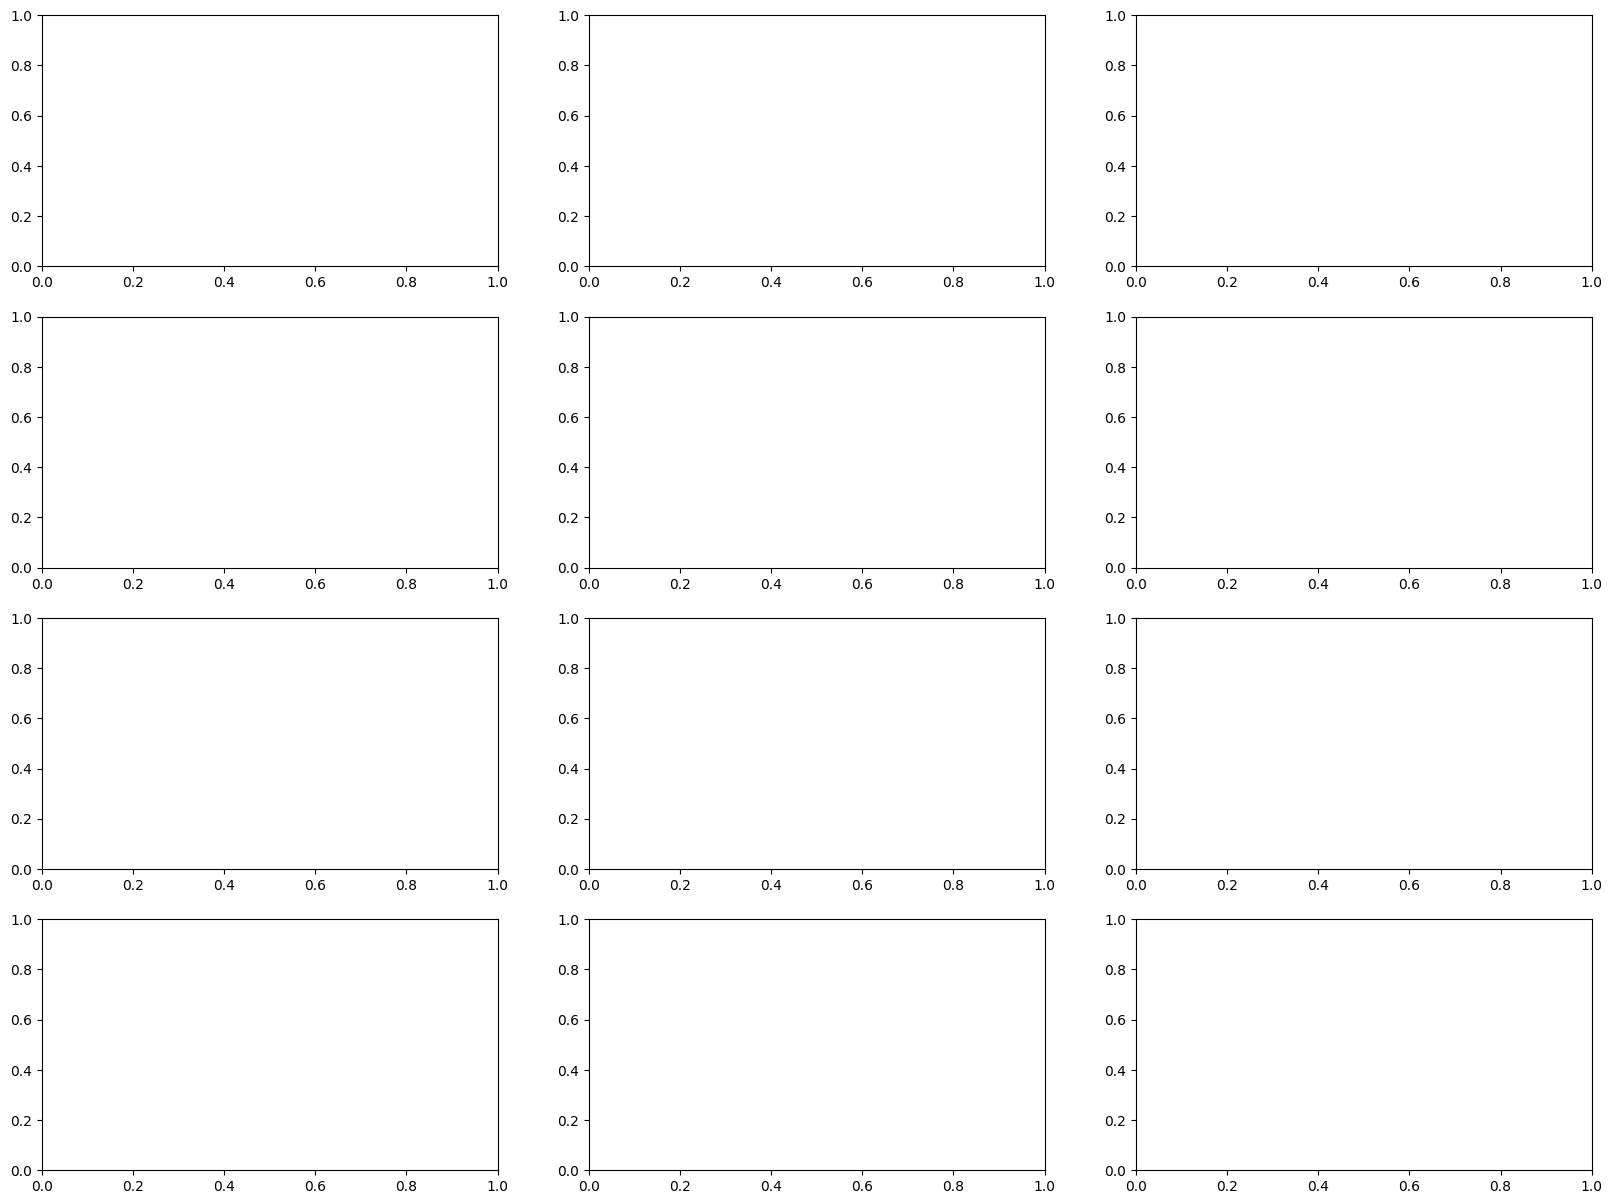

In [ ]:
x_space = np.linspace(0, 2 * np.pi, 100)

# Erstelle Figure mit 2 Zeilen, 3 Spalten
fig, axes = plt.subplots(4, 3, figsize=(20, 15))

# === Zeile 1: Cos-Sin Kombinationen ===

# Fall 1: Cos-Sin | l ≠ k
ax1 = axes[0, 0]
set_axes_cross(ax1)
ax1.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label='$cos(x)$')
ax1.plot(x_space, s_l(2, x_space), color='orange', linewidth=2, label='$sin(2x)$')
ax1.set_xlim(-0.5, 2*np.pi + 0.5)
ax1.set_ylim(-1.5, 1.5)
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axvline(x=np.pi, color='gray', linestyle=':', alpha=0.5)  # Orientierungshilfe
ax1.legend(loc='upper right')
ax1.set_title(r'$\cos(kx), \sin(lx)$ | $l \neq k$')
ax1.text(0, 1.3, r'$k=1, l=2$', ha='center')

# Fall 2: Cos-Sin | l = k ≠ 0
ax2 = axes[0, 1]
set_axes_cross(ax2)
ax2.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label='$cos(x)$')
ax2.plot(x_space, s_l(1, x_space), color='orange', linewidth=2, label='$sin(x)$')
ax2.set_xlim(-0.5, 2*np.pi + 0.5)
ax2.set_ylim(-1.5, 1.5)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.legend(loc='upper right')
ax2.set_title(r'$\cos(kx), \sin(lx)$ | $l = k \neq 0$')
ax2.text(0, 1.3, r'$k=l=1$', ha='center')

# Fall 3: Cos-Sin | l = k = 0
ax3 = axes[0, 2]
set_axes_cross(ax3)
ax3.plot(x_space, c_k(0, x_space), color='blue', linewidth=2, label=r'$cos(0x) = 1$')
ax3.plot(x_space, s_l(0, x_space), color='orange', linewidth=2, label=r'$sin(0x) = 0$')
ax3.axhline(y=1, color='blue', linestyle='--', alpha=0.5)
ax3.axhline(y=0, color='orange', linestyle='-', linewidth=2)
ax3.set_xlim(-0.5, 2*np.pi + 0.5)
ax3.set_ylim(-1.5, 1.5)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.legend(loc='lower right')
ax3.set_title(r'$\cos(kx), \sin(lx)$ | $l = k = 0$')
ax3.text(0, 1.3, r'$k=l=0$', ha='center')


# === Zeile 2: Cos-Sin Flächen ===
# Fall 1: Cos×Sin | l ≠ k
ax1 = axes[1, 0]
set_axes_cross(ax1)
product_1 = c_k(1, x_space) * s_l(2, x_space)
ax1.plot(x_space, product_1, color='purple', linewidth=2, label=r'$\cos(x) \cdot \sin(2x)$')
ax1.fill_between(x_space, product_1, 0, 
                 where=product_1 >= 0, alpha=0.4, color='green', label='Positive Fläche')
ax1.fill_between(x_space, product_1, 0, 
                 where=product_1 < 0, alpha=0.4, color='red', label='Negative Fläche')
ax1.set_xlim(-0.5, 2*np.pi + 0.5)
ax1.set_ylim(-1.5, 1.5)
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.legend(loc='upper right')
ax1.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l \neq k$')
integral_value_1 = np.trapezoid(product_1, x_space)
ax1.text(0, 1.3, f'$k=1, l=2$, ∫≈{integral_value_1:.4f}', ha='center')

# Fall 2: Cos×Sin | l = k ≠ 0
ax2 = axes[1, 1]
set_axes_cross(ax2)
product_2 = c_k(1, x_space) * s_l(1, x_space)
ax2.plot(x_space, product_2, color='purple', linewidth=2, label=r'$\cos(x) \cdot \sin(x)$')
ax2.fill_between(x_space, product_2, 0, 
                 where=product_2 >= 0, alpha=0.4, color='green', label='Positive Fläche')
ax2.fill_between(x_space, product_2, 0, 
                 where=product_2 < 0, alpha=0.4, color='red', label='Negative Fläche')
ax2.set_xlim(-0.5, 2*np.pi + 0.5)
ax2.set_ylim(-1.5, 1.5)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.legend(loc='upper right')
ax2.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l = k \neq 0$')
integral_value_2 = np.trapezoid(product_2, x_space)
ax2.text(0, 1.3, f'$k=l=1$, ∫≈{integral_value_2:.4f}', ha='center')

# Fall 3: Cos×Sin | l = k = 0
ax3 = axes[1, 2]
set_axes_cross(ax3)
product_3 = c_k(0, x_space) * s_l(0, x_space)  # = 1 × 0 = 0
ax3.plot(x_space, product_3, color='purple', linewidth=2, label=r'$\cos(0x) \cdot \sin(0x) = 0$')
ax3.fill_between(x_space, product_3, 0, alpha=0.4, color='gray', label='Fläche = 0')
ax3.set_xlim(-0.5, 2*np.pi + 0.5)
ax3.set_ylim(-1.5, 1.5)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.axhline(y=0, color='orange', linestyle='-', linewidth=3)  # Highlight x-Achse
ax3.legend(loc='upper right')
ax3.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l = k = 0$')
integral_value_3 = np.trapezoid(product_3, x_space)
ax3.text(0, 1.3, f'$k=l=0$, ∫={integral_value_3}', ha='center')

# === Zeile 3: Cos-Cos Kombinationen ===

# Fall 4: Cos-Cos | l ≠ k
ax4 = axes[2, 0]
set_axes_cross(ax4)
ax4.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label=r'$cos(x)$')
ax4.plot(x_space, c_k(2, x_space), color='green', linewidth=2, label=r'$cos(2x)$')
ax4.set_xlim(-0.5, 2*np.pi + 0.5)
ax4.set_ylim(-1.5, 1.5)
ax4.axhline(y=0, color='black', linewidth=0.8)
ax4.legend(loc='upper right')
ax4.set_title(r'$\cos(kx), \cos(lx)$ | $l \neq k$')
ax4.text(0, 1.3, r'$k=1, l=2$', ha='center')

# Fall 5: Cos-Cos | l = k ≠ 0
ax5 = axes[2, 1]
set_axes_cross(ax5)
ax5.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label=r'$cos(x)$')
ax5.plot(x_space, c_k(1, x_space), color='green', linewidth=2, linestyle='--', label=r'$cos(x)$ (identisch)')
ax5.set_xlim(-0.5, 2*np.pi + 0.5)
ax5.set_ylim(-1.5, 1.5)
ax5.axhline(y=0, color='black', linewidth=0.8)
ax5.legend(loc='upper right')
ax5.set_title(r'$\cos(kx), \cos(lx)$ | $l = k \neq 0$')
ax5.text(0, 1.3, r'$k=l=1$', ha='center')

# Fall 6: Cos-Cos | l = k = 0
ax6 = axes[2, 2]
set_axes_cross(ax6)
ax6.plot(x_space, c_k(0, x_space), color='blue', linewidth=2, label=r'$cos(0x) = 1$')
ax6.plot(x_space, c_k(0, x_space), color='green', linewidth=2, linestyle='--', label=r'$cos(0x) = 1$ (identisch)')
ax6.set_xlim(-0.5, 2*np.pi + 0.5)
ax6.set_ylim(-1.5, 1.5)
ax6.axhline(y=0, color='black', linewidth=0.8)
ax6.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax6.legend(loc='lower right')
ax6.set_title(r'$\cos(kx), \cos(lx)$ | $l = k = 0$')
ax6.text(0, 1.3, r'$k=l=0$', ha='center')

# === Zeile 4: Cos × Cos Produkte ===

# Fall 4: Cos×Cos | l ≠ k
ax4 = axes[3, 0]
set_axes_cross(ax4)
product_4 = c_k(1, x_space) * c_k(2, x_space)
ax4.plot(x_space, product_4, color='purple', linewidth=2, label=r'$\cos(x) \cdot \cos(2x)$')
ax4.fill_between(x_space, product_4, 0, 
                 where=product_4 >= 0, alpha=0.4, color='green', label='Positive Fläche')
ax4.fill_between(x_space, product_4, 0, 
                 where=product_4 < 0, alpha=0.4, color='red', label='Negative Fläche')
ax4.set_xlim(-0.5, 2*np.pi + 0.5)
ax4.set_ylim(-1.5, 1.5)
ax4.axhline(y=0, color='black', linewidth=0.8)
ax4.legend(loc='upper right')
ax4.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l \neq k$')
integral_value_4 = np.trapezoid(product_4, x_space)
ax4.text(0, 1.3, f'$k=1, l=2$, ∫≈{integral_value_4:.4f}', ha='center')

# Fall 5: Cos×Cos | l = k ≠ 0
ax5 = axes[3, 1]
set_axes_cross(ax5)
product_5 = c_k(1, x_space) * c_k(1, x_space)  # = cos²(x)
ax5.plot(x_space, product_5, color='purple', linewidth=2, label=r'$\cos^2(x)$')
ax5.fill_between(x_space, product_5, 0, alpha=0.4, color='blue', label='Fläche über x-Achse')
ax5.set_xlim(-0.5, 2*np.pi + 0.5)
ax5.set_ylim(-1.5, 1.5)
ax5.axhline(y=0, color='black', linewidth=0.8)
# ax5.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)  # Mittelwert y=0.5
ax5.legend(loc='upper right')
ax5.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l = k \neq 0$')
integral_value_5 = np.trapezoid(product_5, x_space)
ax5.text(0, 1.3, f'$k=l=1$, ∫≈{integral_value_5:.4f}', ha='center')

# Fall 6: Cos×Cos | l = k = 0
ax6 = axes[3, 2]
set_axes_cross(ax6)
product_6 = c_k(0, x_space) * c_k(0, x_space)  # = 1 × 1 = 1
ax6.plot(x_space, product_6, color='purple', linewidth=2, label=r'$\cos(0x) \cdot \cos(0x) = 1$')
ax6.fill_between(x_space, product_6, 0, alpha=0.4, color='blue', label='Fläche = Rectangle')
ax6.set_xlim(-0.5, 2*np.pi + 0.5)
ax6.set_ylim(-1.5, 1.5)
ax6.axhline(y=0, color='black', linewidth=0.8)
# ax6.axhline(y=1, color='gray', linestyle='--', alpha=0.5)  # Niveau y=1
ax6.legend(loc='upper right')
ax6.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l = k = 0$')
integral_value_6 = np.trapezoid(product_6, x_space)
ax6.text(0, 1.3, f'$k=l=0$, ∫≈{integral_value_6:.4f}', ha='center')


plt.suptitle('Fourier-Basis-Funktionen: Orthogonalitätsfälle', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Platz für Titel lassen

# Speichern und anzeigen
plt.savefig(f'{savefolder}Orthos_alle.pdf')
plt.show()